In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score
import os

path = r"..\Data\SyntheticData\2026_05_23_15_21_27\std_synthetic_data_2026_05_23_15_21_27.csv"
df = pd.read_csv(path)
target = "Problem_SKU"
seed = 1337 
# One-hot encode Storage_Size (drop size_4 as baseline)
size_dummies = pd.get_dummies(df['Storage_Size'], prefix='Size', drop_first=True).astype(int)

# Encode Defect_In_Linked_Receive as 0/1
defect_linked_num = df['Defect_In_Linked_Receive'].astype(int)

# Numeric features (keep standardized)
numeric_features = [
    "Global_SKU_Defect_Rate_%_std",
    "ABS_Volume_Difference_std",
    "Aisle_Hold_%_std",
    "#_Pick_Events_std",
    "#_Pick_Events_In_Clique_std",
    "#_Picks_std",
    "#_Picks_In_Clique_std",
    "Time_In_Loc_std",
    "Current_Max_Volume_std",
]

feature_cols = numeric_features + list(size_dummies.columns) + ['Defect_In_Linked_Receive']

# Combine all properly encoded features
X = df[numeric_features].copy()
X = pd.concat([X, size_dummies, defect_linked_num], axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

dt = DecisionTreeClassifier(
    max_depth=None,        # let it grow; you can cap later
    min_samples_leaf=50,   # mild regularization
    random_state=seed,
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree")
print(classification_report(y_test, y_pred_dt, digits=3))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dt))

import numpy as np

fi_dt = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(fi_dt)

Decision Tree
              precision    recall  f1-score   support

       False      0.970     0.986     0.978     50944
        True      0.782     0.619     0.691      4056

    accuracy                          0.959     55000
   macro avg      0.876     0.802     0.834     55000
weighted avg      0.956     0.959     0.957     55000

ROC AUC: 0.9328285180912574
#_Picks_In_Clique_std           0.326448
#_Pick_Events_In_Clique_std     0.192445
Current_Max_Volume_std          0.118789
#_Picks_std                     0.107028
Aisle_Hold_%_std                0.092016
ABS_Volume_Difference_std       0.052409
Time_In_Loc_std                 0.040231
#_Pick_Events_std               0.039519
Global_SKU_Defect_Rate_%_std    0.030863
Defect_In_Linked_Receive        0.000161
Size_size_2                     0.000080
Size_size_3                     0.000011
Size_size_4                     0.000000
dtype: float64


In [2]:
from sklearn.tree import DecisionTreeClassifier

dt_recall = DecisionTreeClassifier(
    class_weight='balanced',  # ← weights minority class higher
    min_samples_leaf=50,   # same regularization as before
    random_state=seed
)

dt_recall.fit(X_train, y_train)

y_pred_dt = dt_recall.predict(X_test)
y_proba_dt = dt_recall.predict_proba(X_test)[:, 1]

print("Decision Tree")
print(classification_report(y_test, y_pred_dt, digits=3))
print("ROC AUC:", roc_auc_score(y_test, y_proba_dt))

import numpy as np

fi_dt_recall = pd.Series(dt_recall.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(fi_dt_recall)

Decision Tree
              precision    recall  f1-score   support

       False      0.989     0.886     0.935     50944
        True      0.379     0.874     0.529      4056

    accuracy                          0.885     55000
   macro avg      0.684     0.880     0.732     55000
weighted avg      0.944     0.885     0.905     55000

ROC AUC: 0.9351555477747774
#_Picks_In_Clique_std           0.413817
#_Pick_Events_In_Clique_std     0.180206
#_Picks_std                     0.093088
Aisle_Hold_%_std                0.083257
Current_Max_Volume_std          0.078433
ABS_Volume_Difference_std       0.044166
Time_In_Loc_std                 0.036787
#_Pick_Events_std               0.034318
Global_SKU_Defect_Rate_%_std    0.033194
Size_size_3                     0.001564
Size_size_2                     0.000835
Defect_In_Linked_Receive        0.000308
Size_size_4                     0.000027
dtype: float64


## Threshold Tuning for High Precision

The default 0.5 threshold is arbitrary. Since AUC=0.814, the probability scores contain real signal — raising the threshold trades recall for precision on a continuous curve. Find the operating point that hits your precision floor.

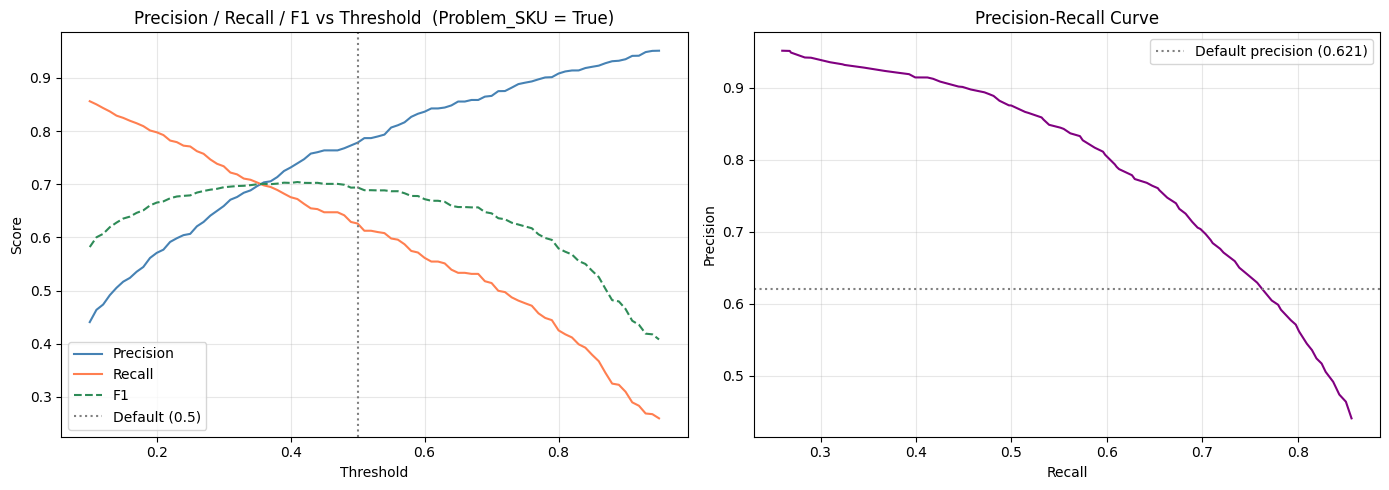


 Prec Target  Threshold   Recall       F1    Flagged   of 4046 True
--------------------------------------------------------------------
        0.70       0.36    0.698    0.701      4,023          2,824
        0.75       0.43    0.655    0.703      3,505          2,649
        0.80       0.55    0.598    0.687      3,007          2,420
        0.85       0.65    0.534    0.657      2,529          2,159
        0.90       0.78    0.449    0.599      2,020          1,816
        0.95       0.94    0.268    0.418      1,142          1,083


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Use the high-precision DT (no class_weight)
y_proba_hp = dt.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.96, 0.01)
precisions, recalls, f1s, n_flagged = [], [], [], []

for t in thresholds:
    y_pred_t = (y_proba_hp >= t).astype(int)
    flagged = y_pred_t.sum()
    if flagged == 0:
        precisions.append(np.nan)
        recalls.append(0.0)
        f1s.append(0.0)
    else:
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
        f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    n_flagged.append(flagged)

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)
n_flagged  = np.array(n_flagged)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresholds, precisions, label="Precision", color="steelblue")
ax.plot(thresholds, recalls,    label="Recall",    color="coral")
ax.plot(thresholds, f1s,        label="F1",        color="seagreen", linestyle="--")
ax.axvline(0.5, color="gray", linestyle=":", label="Default (0.5)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold  (Problem_SKU = True)")
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
valid = ~np.isnan(precisions)
ax2.plot(recalls[valid], precisions[valid], color="purple")
ax2.axhline(0.621, color="gray", linestyle=":", label="Default precision (0.621)")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Precision target table ---
print(f"\n{'Prec Target':>12} {'Threshold':>10} {'Recall':>8} {'F1':>8} {'Flagged':>10} {'of 4046 True':>14}")
print("-" * 68)
for target in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    mask = precisions >= target
    if mask.any():
        # highest recall at or above this precision
        best_idx = np.where(mask)[0][np.argmax(recalls[mask])]
        t  = thresholds[best_idx]
        r  = recalls[best_idx]
        f  = f1s[best_idx]
        nf = n_flagged[best_idx]
        caught = int(round(r * 4046))
        print(f"{target:>12.2f} {t:>10.2f} {r:>8.3f} {f:>8.3f} {nf:>10,} {caught:>14,}")
    else:
        print(f"{target:>12.2f} {'N/A':>10}")


## F1-Optimized Decision Tree

Grid search over class weights and tree structure, scoring directly on F1. Class weight is the main lever — it shifts the model's internal decision boundary without changing the threshold.

In [4]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'max_depth':        [5, 8, 12, None],
    'min_samples_leaf': [20, 50, 100],
    'class_weight': [
        None,
        {False: 1, True: 3},
        {False: 1, True: 5},
        {False: 1, True: 7},
        {False: 1, True: 10},
        'balanced',
    ],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=seed),
    param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
gs.fit(X_train, y_train)

print(f"\nBest params: {gs.best_params_}")
print(f"Best CV F1:  {gs.best_score_:.4f}")

dt_f1 = gs.best_estimator_
y_pred_f1  = dt_f1.predict(X_test)
y_proba_f1 = dt_f1.predict_proba(X_test)[:, 1]

print("\nF1-Optimized Decision Tree (threshold=0.5)")
print(classification_report(y_test, y_pred_f1, digits=3))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_f1):.4f}")

fi_f1 = pd.Series(dt_f1.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(fi_f1)


Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 50}
Best CV F1:  0.6894

F1-Optimized Decision Tree (threshold=0.5)
              precision    recall  f1-score   support

       False      0.970     0.986     0.978     50944
        True      0.782     0.619     0.691      4056

    accuracy                          0.959     55000
   macro avg      0.876     0.802     0.834     55000
weighted avg      0.956     0.959     0.957     55000

ROC AUC: 0.9328

Feature importances:
#_Picks_In_Clique_std           0.326448
#_Pick_Events_In_Clique_std     0.192445
Current_Max_Volume_std          0.118789
#_Picks_std                     0.107028
Aisle_Hold_%_std                0.092016
ABS_Volume_Difference_std       0.052409
Time_In_Loc_std                 0.040231
#_Pick_Events_std               0.039519
Global_SKU_Defect_Rate_%_std    0.030863
Defect_In_Linked_Receive        0.000161
Size_size_2        

F1-maximizing threshold: 0.41  →  F1=0.7043
Precision: 0.739   Recall: 0.672

Classification report at threshold=0.41:
              precision    recall  f1-score   support

       False      0.974     0.981     0.978     50944
        True      0.739     0.672     0.704      4056

    accuracy                          0.958     55000
   macro avg      0.857     0.827     0.841     55000
weighted avg      0.957     0.958     0.957     55000



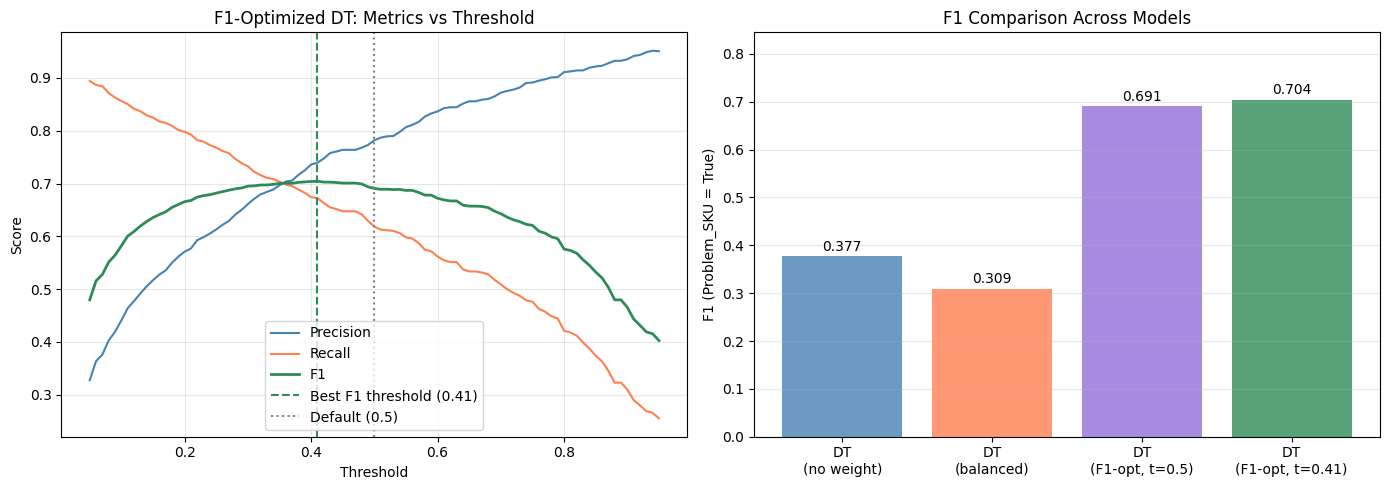

In [5]:
import matplotlib.pyplot as plt

# Sweep threshold on the F1-optimized model to find its best operating point
gs_thresholds = np.arange(0.05, 0.96, 0.01)
gs_precs, gs_recs, gs_f1s, gs_nf = [], [], [], []

for t in gs_thresholds:
    y_pred_t = (y_proba_f1 >= t).astype(int)
    flagged = y_pred_t.sum()
    if flagged == 0:
        gs_precs.append(np.nan)
        gs_recs.append(0.0)
        gs_f1s.append(0.0)
    else:
        gs_precs.append(precision_score(y_test, y_pred_t, zero_division=0))
        gs_recs.append(recall_score(y_test, y_pred_t, zero_division=0))
        gs_f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    gs_nf.append(flagged)

gs_precs = np.array(gs_precs)
gs_recs  = np.array(gs_recs)
gs_f1s   = np.array(gs_f1s)
gs_nf    = np.array(gs_nf)

best_t_idx = int(np.nanargmax(gs_f1s))
best_t     = gs_thresholds[best_t_idx]
best_f1    = gs_f1s[best_t_idx]

print(f"F1-maximizing threshold: {best_t:.2f}  →  F1={best_f1:.4f}")
print(f"Precision: {gs_precs[best_t_idx]:.3f}   Recall: {gs_recs[best_t_idx]:.3f}\n")

y_pred_tuned = (y_proba_f1 >= best_t).astype(int)
print(f"Classification report at threshold={best_t:.2f}:")
print(classification_report(y_test, y_pred_tuned, digits=3))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(gs_thresholds, gs_precs, label="Precision", color="steelblue")
ax.plot(gs_thresholds, gs_recs,  label="Recall",    color="coral")
ax.plot(gs_thresholds, gs_f1s,   label="F1",        color="seagreen", linewidth=2)
ax.axvline(best_t, color="seagreen", linestyle="--",
           label=f"Best F1 threshold ({best_t:.2f})")
ax.axvline(0.5, color="gray", linestyle=":", label="Default (0.5)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("F1-Optimized DT: Metrics vs Threshold")
ax.legend()
ax.grid(alpha=0.3)

# Summary bar chart comparing all models
ax2 = axes[1]
model_names = [
    "DT\n(no weight)",
    "DT\n(balanced)",
    "DT\n(F1-opt, t=0.5)",
    f"DT\n(F1-opt, t={best_t:.2f})",
]
t50_idx = int(np.argmin(np.abs(gs_thresholds - 0.5)))
f1_scores_compare = [
    0.377,
    0.309,
    gs_f1s[t50_idx],
    best_f1,
]
bars = ax2.bar(model_names, f1_scores_compare,
               color=["steelblue", "coral", "mediumpurple", "seagreen"],
               alpha=0.8)
for bar, val in zip(bars, f1_scores_compare):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontsize=10)
ax2.set_ylim(0, max(f1_scores_compare) * 1.2)
ax2.set_ylabel("F1 (Problem_SKU = True)")
ax2.set_title("F1 Comparison Across Models")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
